# Manning's n Region Polygon Authoring and Solver Validation

This workflow authors a calibration-region polygon and regional Manning's n table on the real
`RasExamples` Muncie project, explicitly associates the compiled geometry with terrain and land
cover, recomputes native property tables, and verifies the solver-owned cell-center values before
and after computation.

A layer registered in `.rasmap` is not necessarily associated with the compiled geometry HDF.
`compute_property_tables()` can complete while HEC-RAS silently falls back to the 2D area's scalar
default, so association validation and cell-level HDF audits are required acceptance evidence.

## Setup

In [1]:
from pathlib import Path
import logging
import sys

import matplotlib.pyplot as plt
import numpy as np

repo_root = next(
    candidate
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (candidate / "ras_commander" / "__init__.py").exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from ras_commander import (
    GeomLandCover,
    GeomMesh,
    HdfLandCover,
    HdfMesh,
    RasCmdr,
    RasExamples,
    RasMap,
    RasPlan,
    RasPreprocess,
    RasPrj,
    init_ras_project,
)

logging.getLogger("ras_commander").setLevel(logging.WARNING)

RAS_VERSION = "6.6"
PLAN_NUMBER = "04"
GEOM_NUMBER = "04"
MESH_NAME = "2D Interior Area"
REGION_NAME = "Flat Area"
TARGET_N = 0.123

## Extract and Inspect the Disposable Project

In [2]:
work_dir = repo_root / "working" / "233_mannings_region_polygon_authoring"
work_dir.mkdir(parents=True, exist_ok=True)
project_path = Path(
    RasExamples.extract_project(
        "Muncie",
        output_path=work_dir,
        suffix="233_region_solver_validation",
    )
)

ras = RasPrj()
init_ras_project(
    project_path,
    ras_version=RAS_VERSION,
    ras_object=ras,
    hide_intro=True,
    accept_tcu=True,
)

geom_path = project_path / "Muncie.g04"
geom_hdf = project_path / "Muncie.g04.hdf"
terrain_hdf = project_path / "Terrain" / "TerrainWithChannel.hdf"
landcover_hdf = project_path / "LandCover" / "LandCoverUserShapefile.hdf"
plan_hdf = project_path / "Muncie.p04.hdf"

before = RasMap.list_geometry_associations(
    geom_number=GEOM_NUMBER,
    ras_object=ras,
)
before[[
    "geom_number",
    "plan_numbers",
    "terrain_hdf_path",
    "landcover_hdf_path",
    "has_spatial_mannings",
]]

2026-09-26 06:55:51 - ras_commander.RasPrj - WARNING - Skipping HDF results summary for plan 01 because hdf is the selected result format


2026-09-26 06:55:51 - ras_commander.RasPrj - WARNING - Skipping HDF results summary for plan 03 because hdf is the selected result format


2026-09-26 06:55:51 - ras_commander.RasPrj - WARNING - Skipping HDF results summary for plan 04 because hdf is the selected result format


,geom_number,plan_numbers,terrain_hdf_path,landcover_hdf_path,has_spatial_mannings
0,04,"(04,)",None,None,True


## Author the Calibration Region and Regional Table

The source geometry HDF already contains the GUI-authored `Flat Area` polygon. Read that real
polygon, write it through the plain-text authoring API, then assign a conspicuous 0.123 value to
every class in the region table so propagation is easy to prove.

In [3]:
regions = HdfLandCover.get_mannings_region_polygons(geom_hdf)
mesh_areas = HdfMesh.get_mesh_areas(geom_hdf)
flat_area = regions.loc[
    regions["Name"].astype(str).str.strip().eq(REGION_NAME)
].copy()
assert len(flat_area) == 1, "Expected one Muncie 'Flat Area' region"

GeomLandCover.set_mannings_region_polygons(
    geom_path,
    flat_area[["Name", "geometry"]],
)
region_n = GeomLandCover.get_region_mannings_n(geom_path)
target_rows = region_n.loc[region_n["Region Name"].eq(REGION_NAME)].copy()
assert not target_rows.empty, "Expected an existing regional Manning table"
target_rows["MainChannel"] = TARGET_N
GeomLandCover.set_region_mannings_n(geom_path, target_rows)

authored_rows = GeomLandCover.get_region_mannings_n(geom_path)
authored_rows = authored_rows.loc[
    authored_rows["Region Name"].eq(REGION_NAME)
].reset_index(drop=True)
assert np.allclose(authored_rows["MainChannel"], TARGET_N)
assert geom_path.with_suffix(".g04.bak").exists()
authored_rows

,Table Number,Land Cover Name,MainChannel,Region Name
0,6,building,0.123,Flat Area
1,6,medium density residential,0.123,Flat Area
2,6,open space,0.123,Flat Area
3,6,park,0.123,Flat Area
4,6,trees,0.123,Flat Area
5,6,urban,0.123,Flat Area


## Associate, Validate, and Recompute Property Tables

The exact HDF paths are explicit. Omitting a path from a later setter call preserves the existing
association, but a registered `.rasmap` layer alone is not accepted as proof. The validation gate
runs before native property-table generation.

In [4]:
RasMap.set_geometry_association(
    GEOM_NUMBER,
    terrain_hdf_path=terrain_hdf,
    landcover_hdf_path=landcover_hdf,
    ras_object=ras,
)
association_report = RasMap.validate_geometry_associations(
    geom_number=GEOM_NUMBER,
    required_layers=("terrain", "landcover"),
    require_existing_paths=True,
    ras_object=ras,
)

property_tables_ok = GeomMesh.compute_property_tables(
    GEOM_NUMBER,
    mesh_name=MESH_NAME,
    force=True,
    ras_object=ras,
)
assert property_tables_ok
association_report[[
    "geom_number",
    "plan_numbers",
    "terrain_hdf_path",
    "landcover_hdf_path",
    "passed",
]]

,geom_number,plan_numbers,terrain_hdf_path,landcover_hdf_path,passed
0,04,"(04,)",C:\Users\bill\.config\superpowers\worktrees\ra...,C:\Users\bill\.config\superpowers\worktrees\ra...,True


## Pre-Compute Gold Standard: Temporary Plan HDF

Geometry preprocessing creates the temporary plan HDF used to prepare the computation. Validate
the solver-owned `Cells Center Manning's n` array here—not merely the calibration table or region
mapping—before launching the hydraulic run.

In [5]:
plan_path = RasPlan.get_plan_path(PLAN_NUMBER, ras_object=ras)
RasPlan.update_run_flags(
    plan_path,
    geometry_preprocessor=True,
    ras_object=ras,
)
preprocess = RasPreprocess.preprocess_plan(
    PLAN_NUMBER,
    ras_object=ras,
    max_wait=600,
    clear_existing=True,
    fix_line_endings=True,
)
assert preprocess

precompute_audit = HdfLandCover.audit_final_mannings_n(
    preprocess.tmp_hdf_path,
    mesh_name=MESH_NAME,
    minimum_cell_distinct_values=2,
    expected_cell_values=[TARGET_N],
    require_complete_geometry=False,
)
precompute_audit[[
    "mesh_name",
    "landcover_filename",
    "cell_distinct_values",
    "missing_expected_cell_values",
    "passed",
]]

,mesh_name,landcover_filename,cell_distinct_values,missing_expected_cell_values,passed
0,2D Interior Area,.\LandCover\LandCoverUserShapefile.hdf,"(0.03999999910593033, 0.05999999865889549, 0.0...",(),True


## Post-Compute Gold Standard: Final Plan HDF

Run through the normal ras-commander execution API and repeat the cell-level audit on the completed
plan HDF. A successful process exit is necessary but not sufficient evidence of Manning propagation.

In [6]:
compute = RasCmdr.compute_plan(
    PLAN_NUMBER,
    ras_object=ras,
    force_rerun=True,
    num_cores=2,
    verify=True,
)
assert compute.success and compute.completion_verified

postcompute_audit = HdfLandCover.audit_final_mannings_n(
    plan_hdf,
    mesh_name=MESH_NAME,
    minimum_cell_distinct_values=2,
    expected_cell_values=[TARGET_N],
)
postcompute_audit[[
    "mesh_name",
    "complete_geometry",
    "cell_distinct_values",
    "missing_expected_cell_values",
    "passed",
]]

2026-09-26 06:56:02 - ras_commander.RasDialogWatchdog - WARNING - DialogWatchdog requires pywin32 (win32gui); dialogs will NOT be auto-dismissed. Install pywin32 on Windows or pass dialog_watchdog=False to disable this watchdog.


,mesh_name,complete_geometry,cell_distinct_values,missing_expected_cell_values,passed
0,2D Interior Area,True,"(0.03999999910593033, 0.05999999865889549, 0.0...",(),True


## Visual Confirmation of Solver Cell Values

Join the final per-cell Manning array to public mesh-cell points and the native `Internal Cells`
region mapping. Nearly every mapped cell carries 0.123; HEC-RAS retains the base value on one
boundary cell in this fixture, which is reported rather than hidden.

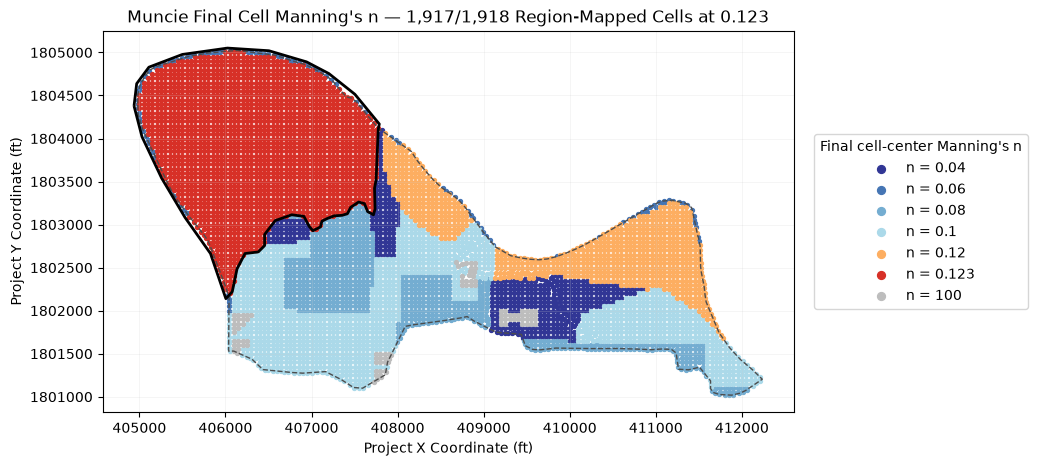

In [7]:
cell_points = HdfMesh.get_mesh_cell_points(plan_hdf)
cell_points = cell_points.loc[
    cell_points["mesh_name"].eq(MESH_NAME),
    ["mesh_name", "cell_id", "geometry"],
].copy()
cell_n = HdfLandCover.get_preprocessed_mannings_n(
    plan_hdf,
    mesh_name=MESH_NAME,
)
mapped = cell_points.merge(cell_n, on=["mesh_name", "cell_id"], how="inner")

region_mapping = HdfLandCover.get_mannings_region_cell_mapping(plan_hdf)
region_cell_ids = region_mapping.loc[
    region_mapping["region_id"].eq(int(flat_area["region_id"].iloc[0])),
    "cell_index",
]
region_values = cell_n.set_index("cell_id").loc[region_cell_ids, "mannings_n"]
override_count = int(np.isclose(region_values, TARGET_N).sum())
assert len(region_values) > 0
assert override_count / len(region_values) > 0.99

fig, ax = plt.subplots(figsize=(10.5, 6.5))
mesh_areas.boundary.plot(
    ax=ax,
    color="#4d4d4d",
    linewidth=1.0,
    linestyle="--",
)
value_colors = {
    0.04: "#313695",
    0.06: "#4575b4",
    0.08: "#74add1",
    0.10: "#abd9e9",
    0.12: "#fdae61",
    TARGET_N: "#d73027",
    100.0: "#bdbdbd",
}
for value in sorted(mapped["mannings_n"].unique()):
    matching = mapped.loc[np.isclose(mapped["mannings_n"], value)]
    color = next(
        (
            candidate_color
            for candidate_value, candidate_color in value_colors.items()
            if np.isclose(value, candidate_value)
        ),
        "#252525",
    )
    matching.plot(
        ax=ax,
        color=color,
        markersize=8,
        label=f"n = {value:g}",
    )
flat_area.boundary.plot(ax=ax, color="#000000", linewidth=2.0)
ax.set_title(
    f"Muncie Final Cell Manning's n — {override_count:,}/{len(region_values):,} Region-Mapped Cells at {TARGET_N:g}"
)
ax.set_xlabel("Project X Coordinate (ft)")
ax.set_ylabel("Project Y Coordinate (ft)")
ax.set_aspect("equal", adjustable="box")
ax.ticklabel_format(style="plain", useOffset=False)
ax.grid(True, color="#cccccc", linewidth=0.4, alpha=0.35)
ax.legend(
    title="Final cell-center Manning's n",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    markerscale=2.0,
)
plt.tight_layout()
plt.show()

## Manual Review Still Matters

The API gates prove the compiled associations and solver-owned arrays, but manual diagnostics remain
advisable. Open the disposable project in RAS Mapper, confirm the geometry's terrain and land-cover
associations, inspect the final Manning surface, and review boundary-cell behavior. A missing
association is exactly the kind of setup mistake that visual model review should catch—and HEC-RAS
may not report it in runtime messages.